# <center> Обучение с учителем. Классификация. Практика

## <center> Прогнозирование оттока клиентов банка

## Постановка задачи

Теперь настало время самостоятельной работы. В рамках самостоятельной работы вам предстоит решить задачу прогнозирования оттока клиентов банка. 

> **Примечание.** Вы уже знакомились с этой задачей в модуле по визуализации («PYTHON-13. Визуализация данных») и провели небольшое исследование данных. Вы можете использовать результаты своего исследования для построения модели машинного обучения.

Напомним контекст задачи:

> Некоторый банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдёт ли клиент в ближайшее время. 

Итак, ранее вы провели небольшой разведывательный анализ, познакомились с данными и выявили, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов. Вы отлично справились с первой задачей, и теперь представители банка предлагают вам построить саму модель машинного обучения, которая будет прогнозировать отток клиентов. 

**Ваша задача** - построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

Разделим эту задачу на две части:
* В первой части мы подготовим данные для моделирования и построим простейшую модель логистической регрессии, оценим её качество и проанализируем результаты её работы.

* Во второй части мы займёмся построением моделей дерева решений и случайного леса, сравним их результаты с результатами, полученными на первом этапе, и сделаем финальный вывод.


Для начала импортируем библиотеки, которые нам понадобятся:

In [1]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import model_selection #сплитование выборки
from sklearn import preprocessing #предобработка данных
%matplotlib inline

Итак, прочитаем нашу таблицу:

In [2]:
churn_data = pd.read_csv('data/churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Практика: логистическая регрессия

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9:

### Задание 5.0 (не оценивается)

Для полноты задачи проведите небольшой разведывательный анализ данных. Постройте графики распределения целевого признака, диаграммы и графики, показывающие взаимосвязь между исходными признаками и целевым признаком, а также другие диаграммы, иллюстрирующие предоставленные данные. 

**Совет:** воспользуйтесь кодом, который вы писали, выполняя задания в модуле «PYTHON-13. Визуализация данных».

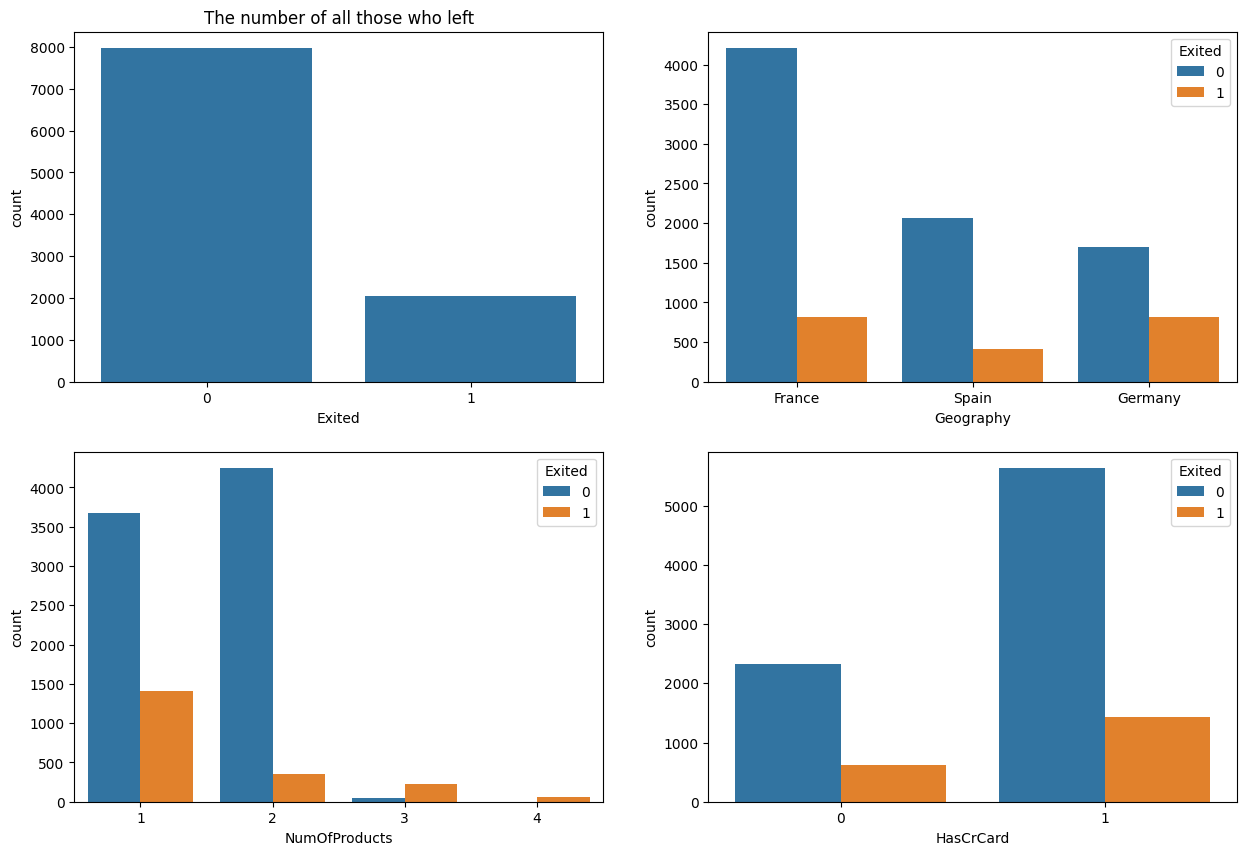

In [3]:
# Ваш код здесь
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=churn_data, x = 'Exited', ax=axes[0, 0])
axes[0, 0].set_title('The number of all those who left')
sns.countplot(data=churn_data, x='Geography', hue='Exited', ax=axes[0, 1])
sns.countplot(data=churn_data, x='NumOfProducts', hue='Exited', ax=axes[1, 0])
sns.countplot(data=churn_data, x='HasCrCard', hue='Exited', ax=axes[1, 1])
display()

В модуле по визуализации мы выяснили, что отток в Германии, Франции и Испании имеет различные показатели. Исследователи, которые уже работали с этим датасетом, пришли к выводу, что наилучшее решение при работе с этими данными — строить модели индивидуально для каждой страны. Мы будем прогнозировать отток в немецком филиале банка. Давайте выделим только данные, относящиеся к Германии:

In [4]:
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 14)

Сразу избавимся от заведомо неинформативных признаков: страна, номер строки, идентификатор пользователя и имя клиента.

In [5]:
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Female,29,4,115046.74,4,1,0,119346.88,1
15,616,Male,45,3,143129.41,2,0,1,64327.26,0
16,653,Male,58,1,132602.88,1,1,0,5097.67,1
26,756,Male,36,2,136815.64,1,1,1,170041.95,0
28,574,Female,43,3,141349.43,1,1,1,100187.43,0


Проверим, что в наших данных нет пропусков:

In [6]:
churn_data.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Проверим, что в наших данных нет дубликатов:

In [7]:
churn_data.duplicated().sum()

np.int64(0)

### Задание 5.1 (1 балл)

Давайте сделаем предобработку данных. 

Для начала расширим датасет с помощью методов Feature Engineering. Создайте следующие признаки:
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Затем перекодируйте оставшиеся текстовые категориальные признаки в числовые бинарные столбцы.

Выведите основные статистические характеристики полученных признаков.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания указанных в задании признаков;
    * приведён код для кодирования категориальных признаков в числовые бинарные столбцы;
    * приведён код для расчёта основных статистических характеристик полученных признаков.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [8]:
# Ваш код здесь
churn_data['BalanceSalaryRatio'] = churn_data['Balance'] / churn_data['EstimatedSalary']
churn_data['TenureByAge'] = churn_data['Tenure'] / churn_data['Age']
churn_data['CreditScoreGivenAge'] = churn_data['CreditScore'] / churn_data['Age']

churn_data.info() # Категориальный признак только у Gender

gender_encoded = pd.get_dummies(churn_data, columns=['Gender'], drop_first=True)
churn_data = gender_encoded
churn_data.head()

# Основные статистические характеристики
churn_data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2509 entries, 7 to 9998
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CreditScore          2509 non-null   int64  
 1   Gender               2509 non-null   object 
 2   Age                  2509 non-null   int64  
 3   Tenure               2509 non-null   int64  
 4   Balance              2509 non-null   float64
 5   NumOfProducts        2509 non-null   int64  
 6   HasCrCard            2509 non-null   int64  
 7   IsActiveMember       2509 non-null   int64  
 8   EstimatedSalary      2509 non-null   float64
 9   Exited               2509 non-null   int64  
 10  BalanceSalaryRatio   2509 non-null   float64
 11  TenureByAge          2509 non-null   float64
 12  CreditScoreGivenAge  2509 non-null   float64
dtypes: float64(5), int64(7), object(1)
memory usage: 274.4+ KB


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
count,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.00000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000
mean,651.453567,39.771622,5.009964,119730.116134,1.519729,0.71383,0.497409,101113.435102,0.324432,9.024870,0.134303,17.526487
std,98.168937,10.519143,2.935154,27022.006157,0.619420,0.45206,0.500093,58263.011501,0.468256,214.286020,0.087680,5.349558
min,350.000000,18.000000,0.000000,27288.430000,1.000000,0.00000,0.000000,11.580000,0.000000,0.192582,0.000000,6.112676
25%,584.000000,32.000000,2.000000,102800.720000,1.000000,0.00000,0.000000,51016.020000,0.000000,0.783284,0.060606,13.686275
50%,651.000000,38.000000,5.000000,119703.100000,1.000000,1.00000,0.000000,102397.220000,0.000000,1.197220,0.125000,16.857143
75%,722.000000,45.000000,8.000000,137560.380000,2.000000,1.00000,1.000000,151083.800000,1.000000,2.400083,0.200000,20.852941
max,850.000000,84.000000,10.000000,214346.960000,4.000000,1.00000,1.000000,199970.740000,1.000000,10614.655440,0.500000,46.388889


Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет). 

In [9]:
X = churn_data.drop("Exited", axis=1)
y = churn_data["Exited"]

Прежде чем перейти к этапу разделения выборки на тренировочную и тестовую, давайте посмотрим на сбалансированность данных. Для этого воспользуемся методом `value_counts()` и выведем количество наблюдений каждого из классов в долевом соотношении от общего количества наблюдений:

In [10]:
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


**К чему это может привести?**

При разделении набора данных на тренировочный и тестовый может возникнуть такая ситуация, что в тренировочную выборку попадут только лояльные клиенты или их большая часть. Тогда модель может не научиться определять вероятность оттока и качество на тестовой выборке будет неудовлетворительным.

Или противоположная ситуация: в тестовую выборку попадут только лояльные клиенты. Тогда модель будет показывать отличное качество на тестовой выборке, но в реальных условиях она может оказаться бесполезной.

То есть нам нужно сделать так, чтобы в тренировочной и тестовой выборке было одинаковое соотношение лояльных и ушедших клиентов. Такое разбиение выборки называется **стратифицированным**. 

Функция `train_test_split()` из библиотеки `sklearn` умеет производить такое разбиение. Для этого в ней предусмотрен параметр `stratify`, который нужно выставить в значение признака, который должен иметь одинаковые соотношения в тренировочной и тестовой выборке. У нас этот признак - это целевой признак y. 

Выполним разбиение, установив значение параметра `random_state` на 0:


In [11]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:

In [12]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.

In [13]:
churn_data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Male
7,376,29,4,115046.74,4,1,0,119346.88,1,0.963969,0.137931,12.965517,False
15,616,45,3,143129.41,2,0,1,64327.26,0,2.225020,0.066667,13.688889,True
16,653,58,1,132602.88,1,1,0,5097.67,1,26.012449,0.017241,11.258621,True
26,756,36,2,136815.64,1,1,1,170041.95,0,0.804599,0.055556,21.000000,True
28,574,43,3,141349.43,1,1,1,100187.43,0,1.410850,0.069767,13.348837,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9982,655,46,7,137145.12,1,1,0,115146.40,1,1.191050,0.152174,14.239130,False
9984,602,35,7,90602.42,2,1,1,51695.41,0,1.752620,0.200000,17.200000,True
9986,673,47,1,183579.54,2,0,1,34047.54,0,5.391859,0.021277,14.319149,True
9990,714,33,3,35016.60,1,1,0,53667.08,0,0.652478,0.090909,21.636364,True


### Задание 5.2 (1 балл)

Позаботьтесь о масштабировании признаков. Проведите нормализацию/стандартизацию матрицы наблюдений `X` с помощью `MinMaxScaler`/`RobustScaler` или `StandardScaler`. Выберите метод самостоятельно.

Обучите один из предложенных скейлеров на тренировочной выборке (вычислите параметры трансформации) и примените трансформацию данных к тренировочной и тестовой выборкам.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания одного из вариантов скейлеров для масштабирования данных;
    * приведён код для расчёта параметров трансформации (обучение скейлера) на тренировочной выборке;
    * приведён код для трансформации тренировочных и тестовых данных (признаков) в соответствии с вычисленными параметрами.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [14]:
# Ваш код здесь
value_categories = [ 
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary',
    'BalanceSalaryRatio',
    'TenureByAge',
    'CreditScoreGivenAge']
scaler = preprocessing.RobustScaler()
scaler.fit(X_train[value_categories])
X_train[value_categories] = scaler.transform(X_train[value_categories])
X_test[value_categories] = scaler.transform(X_test[value_categories])

Теперь переходим к моделированию.

### Задание 5.3 (1 балл)

Для начала давайте заранее определим метрику, на которую будем ориентироваться. 

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы колл-центра и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор. 


> Укажите название метрики и обоснования своего выбора здесь

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * выбрана верная метрика;
    * приведено развернутое обоснование выбора метрики, и приведенные рассуждения являются верными;

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

> Ваши рассуждения и ответ — *здесь*.

Учитывая имеющиеся данные о количестве клиентов, которые собираются уходить и не собираются, можно сделать вывод что классы не сбалансированы. Это главная информация при выборе метрики. Банку важно как можно больше клиентов удержать в их структуре и одновременно не тратить много ресурсов для связи с теми клиентами, которые не хотят терять услуги банка.

Если модель решила, что клиент не хочет уходить, однако клиент хочет уйти то это связано с recall. Если же модель решила, что клиент уходит, однако на самом деле нет, это связано с precision. Для достижения баланса между этими двумя метриками нам поможет F1 мера.    

### Задание 5.4 (2 балла)

Обучите модель логистической регрессии (`Logistic Regression`) на тренировочных данных. Позаботьтесь о воспроизводимости результата, установив конкретное значение параметра `random_state` (например, число 42).

Сделайте предсказание меток классов для тренировочной и тестовой выборок. 

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках. 

Проинтерпретируйте полученные результаты, ответив на следующий вопрос:
* Как вы считаете, является ли ваша модель переобученной или недообученной?

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель логистической регрессии, решающая поставленную задачу;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [15]:
X_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Male
5641,0.172662,0.307692,-0.6,-0.776599,2,1,0,-0.908725,5.814714,-0.594802,-0.122906,True
5780,-0.338129,0.307692,1.0,1.331832,1,1,0,-0.040037,0.298168,0.811094,-0.359393,False
8131,-0.273381,-0.384615,-0.4,1.036165,2,1,1,-0.432546,0.907509,-0.275280,0.227433,True
49,0.899281,-0.076923,-0.6,-0.456303,2,1,0,0.887515,-0.400073,-0.547306,0.562788,False
4666,1.431655,0.076923,0.0,-0.148356,1,1,0,-0.026518,-0.028816,0.000000,0.677766,False
...,...,...,...,...,...,...,...,...,...,...,...,...
346,-0.151079,-0.307692,0.8,-0.365325,2,1,0,0.347050,-0.255683,1.007506,0.220950,False
3780,-0.402878,0.615385,0.0,0.652020,2,1,0,-0.522873,1.054688,-0.143999,-0.561703,True
5466,1.431655,-0.461538,-0.4,0.518579,1,0,1,0.551609,-0.200908,-0.254312,1.344727,True
110,0.244604,-0.615385,-0.4,-0.836330,1,0,1,-0.380927,0.144588,-0.208181,0.823040,True


In [16]:
# Ваш код
log_model = linear_model.LogisticRegression(random_state=42, max_iter=5000)
log_model.fit(X_train, y_train)
y_pred_train = log_model.predict(X_train)
y_pred_test = log_model.predict(X_test)


In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

print('Train:')
print('Accuracy:', accuracy_score(y_train, y_pred_train))
print('Precision:', precision_score(y_train, y_pred_train))
print('Recall:', recall_score(y_train, y_pred_train))
print('F1:', f1_score(y_train, y_pred_train))

print('\nTest:')
print('Accuracy:', accuracy_score(y_test, y_pred_test))
print('Precision:', precision_score(y_test, y_pred_test))
print('Recall:', recall_score(y_test, y_pred_test))
print('F1:', f1_score(y_test, y_pred_test))

Train:
Accuracy: 0.7331206804891015
Precision: 0.6279620853080569
Recall: 0.4344262295081967
F1: 0.5135658914728682

Test:
Accuracy: 0.7213375796178344
Precision: 0.6013986013986014
Recall: 0.4215686274509804
F1: 0.4956772334293948


> Ваши выводы и рассуждения — *здесь*.

Полученные результаты показывают незначительное ухудшение показателей на тестовой выборке. Главный вывод заключается в том, что из за не значительной разницы между тренировачными и тестовыми выборками нет переобучения. 

Результаты на тестовой выборке показывают, что precision равен около 0.60, что означает модель улавливает лишь 60% клиентов из тех, кого она определила как уходящих. Recall равен 0.42, что означает, что модель улавливает лишь 42% клиентов, которые действительно уходят, пропуская значительную часть. 

Таким образом, приоритетной задачей должно быть улучшение метрик recall, ввиду необходимости банка сдержать как можно больше клиентов в своей структуре. 

### Задание 5.5 (2 балла)

Сгенерируйте полиномиальные признаки третьей степени для тренировочной и тестовой выборок. Используйте класс `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` выставите в значение `False`.

> **Примечание.** Обратите внимание, что для генерации полиномов необходимо использовать масштабированные данные.

Обучите модель логистической регрессии на полиномиальных признаках (`Logistic Regression`). Позаботьтесь о воспроизводимости результат, установив конкретное значение параметра `random_state` (например, число 42).

Предскажите метки классов для тренировочной и тестовой выборок.

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках для модели, обученной на полиномиальных признаках.

Сравните результат с полученным ранее. Удалось ли вам улучшить качество вашей модели?

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * сгенерированы полиномиальные признаки третьей степени;
    * построена модель логистической регрессии, решающая поставленную задачу на основе сгенерированных признаков;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [18]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Male
3827,1.028777,1.461538,-0.4,-0.074701,1,1,0,-0.088021,0.035076,-0.557805,-0.422503,True
1004,-0.359712,-0.923077,0.4,-0.406174,2,1,0,-0.506907,0.551073,1.040904,0.862498,False
2945,1.323741,-1.384615,-0.2,0.135208,1,0,0,0.752928,-0.306004,0.529915,3.469360,True
6231,-0.143885,0.769231,-0.8,-0.380850,1,1,1,0.466970,-0.296306,-0.792506,-0.532178,True
8277,-0.194245,0.153846,-0.4,0.870327,2,1,0,0.021129,0.143571,-0.392705,-0.188856,False
...,...,...,...,...,...,...,...,...,...,...,...,...
5559,1.431655,-0.153846,0.0,0.009378,1,1,0,0.862691,-0.344545,0.078856,0.931846,True
3716,0.100719,-0.846154,-0.6,0.797781,1,0,0,0.823703,-0.247865,-0.399539,1.074331,False
3885,-0.064748,1.384615,0.2,-0.471362,2,1,0,0.393277,-0.286904,-0.155460,-0.767416,False
983,-0.266187,-0.230769,0.2,0.242471,1,0,0,-0.319243,0.392054,0.319030,0.082937,False


In [19]:
# Ваш код здесь
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Обучение на полиномиальных данных модель логистической регрессии
log_model_poly = linear_model.LogisticRegression(random_state=42, max_iter=20000, C=1)
log_model_poly.fit(X_train_poly, y_train)

y_pred_train_poly = log_model_poly.predict(X_train_poly)
y_pred_test_poly = log_model_poly.predict(X_test_poly)


/Users/tural/Desktop/Project3/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 8653 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Метрики
print('Train (Polynomial Features):')
print('Accuracy:', accuracy_score(y_train, y_pred_train_poly))
print('Precision:', precision_score(y_train, y_pred_train_poly))
print('Recall:', recall_score(y_train, y_pred_train_poly))
print('F1:', f1_score(y_train, y_pred_train_poly))

print('\nTest (Polynomial Features):')
print('Accuracy:', accuracy_score(y_test, y_pred_test_poly))
print('Precision:', precision_score(y_test, y_pred_test_poly))
print('Recall:', recall_score(y_test, y_pred_test_poly))
print('F1:', f1_score(y_test, y_pred_test_poly))

Train (Polynomial Features):
Accuracy: 0.8463583200425305
Precision: 0.8034026465028355
Recall: 0.6967213114754098
F1: 0.746268656716418

Test (Polynomial Features):
Accuracy: 0.785031847133758
Precision: 0.6971428571428572
Recall: 0.5980392156862745
F1: 0.6437994722955145


> Ваши выводы и рассуждения — *здесь*

Несмотря на улучшение метрик в сравнении с базовой модели, я получил предупреждение о том, что оптимизатор не сошелся после 8875 итераций. Для получения оптимальной оценки метрик и также качества модели попробуем поменять оптимизатор с lbfgs на saga. Saga рассчитан для работы с датасетами где большое количество признаков и высокой размерностью данных.

In [21]:
# Оптимизатор saga
log_model_poly_saga = linear_model.LogisticRegression(
    random_state=42, 
    max_iter=5000, 
    solver='saga', 
    C=10)

log_model_poly_saga.fit(X_train_poly, y_train)
y_pred_train_poly_saga = log_model_poly_saga.predict(X_train_poly)
y_pred_test_poly_saga = log_model_poly_saga.predict(X_test_poly)

# Метрики
print('Train (Polynomial + saga):')
print('Accuracy:', accuracy_score(y_train, y_pred_train_poly_saga))
print('Precision:', precision_score(y_train, y_pred_train_poly_saga))
print('Recall:', recall_score(y_train, y_pred_train_poly_saga))
print('F1:', f1_score(y_train, y_pred_train_poly_saga))

print('\nTest (Polynomial + saga):')
print('Accuracy:', accuracy_score(y_test, y_pred_test_poly_saga))
print('Precision:', precision_score(y_test, y_pred_test_poly_saga))
print('Recall:', recall_score(y_test, y_pred_test_poly_saga))
print('F1:', f1_score(y_test, y_pred_test_poly_saga))

Train (Polynomial + saga):
Accuracy: 0.5172780435938331
Precision: 0.33590308370044053
Recall: 0.5
F1: 0.4018445322793149

Test (Polynomial + saga):
Accuracy: 0.517515923566879
Precision: 0.33663366336633666
Recall: 0.5
F1: 0.40236686390532544


В попытке убрать ошибку о несходимости оптимизатора я столкнулся с недообучением модели. Метркии, не имеющие существенной разницы на тренировочной и тестовых выборках, оказались низкими. Следовательно, я оставляю выбор на оптимизаторе lbfgs и попробую улучшить качество модели путем подбора порога вероятности. 



### Задание 5.6. (2 балла)


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. В качестве модели используйте логистическую регрессию, обученную на полиномиальных признаках. 

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список.

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученными ранее.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для построения графика зависимости значения выбранной метрики от порога вероятности;
    * найден оптимальный порог вероятности, на котором достигается наибольшее значение выбранной метрики на тестовой выборке;
    * на основе найденного порога вероятности построено предсказание модели для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [22]:
# Ваш код здесь
y_test_proba_pred = pd.Series(log_model_poly.predict_proba(X_test_poly)[:, 1])
scores = []
thresholds = np.arange(0.1, 1, 0.05)

for threshold in thresholds:
    y_test_pred_threshold = y_test_proba_pred.apply(lambda x: 1 if x>threshold else 0)
    score = metrics.f1_score(y_test, y_test_pred_threshold)
    scores.append(score)

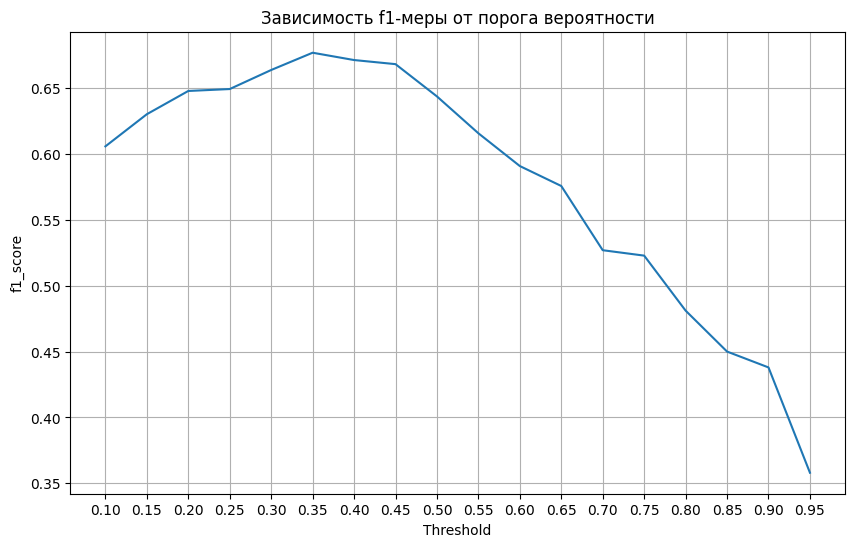

In [23]:
# График
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, scores)
ax.set_xticks(thresholds)
ax.set_title('Зависимость f1-меры от порога вероятности')
plt.grid(True)
plt.xlabel('Threshold')
plt.ylabel('f1_score')
display()

In [24]:
# Метрики на основе нового порога вероятности
best_score = max(scores)
best_threshold = thresholds[scores.index(best_score)]

y_test_pred_best = y_test_proba_pred.apply(lambda x: 1 if x > best_threshold else 0)
print("Best threshold:", best_threshold)
print("F1:", f1_score(y_test, y_test_pred_best))
print("Precision:", precision_score(y_test, y_test_pred_best))
print("Recall:", recall_score(y_test, y_test_pred_best))
print("Accuracy:", accuracy_score(y_test, y_test_pred_best))

Best threshold: 0.3500000000000001
F1: 0.6769911504424779
Precision: 0.6169354838709677
Recall: 0.75
Accuracy: 0.767515923566879


На основе анализа зависимости F1-меры от порога классификации был выбран оптимальный порог 0.35, при котором достигается наибольшее значение целевой метрики. Использование данного порога вместо стандартного 0.5 позволило улучшить баланс между precision и recall и повысить итоговую F1-меру.

## Практика: деревья решений и случайный лес

Мы продолжаем решать задачу прогнозирования оттока клиентов банка.

Ранее мы построили модель логистической регрессии, затем добавили в модель полиномиальные признаки и подобрали оптимальный порог вероятности для логистической регрессии.

> Теперь попробуем решить задачу с помощью деревьев решений и лесов.


> **Примечание №1.** Для выполнения дальнейших заданий необходимо совершить уже знакомые шаги предобработки с данными об оттоке клиентов банка, а именно:
* выделить данные, относящиеся к отделениям банка в Германии;
* избавиться от заведомо неинформативных признаков;
* расширить датасет путём добавления новых признаков;
* разделить выборку на тренировочную и тестовую со стратификацией.

> **Примечание №2.** Деревья решений — алгоритм, способный уловить нелинейные зависимости. Генерация полиномиальных признаков практически не имеет значения.
Также деревья решений не чувствительны к масштабу признаков. Масштабирование исходных данных не играет роли при построении деревьев решения.
Поэтому для решения задачи используйте обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки без полиномиальных столбцов.


In [25]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Импортируем необходимые для выполнения практики модули:

In [26]:
from sklearn import tree
from sklearn import ensemble

Приступим! Выполните задания 8.1–8.4.

### Задание 8.1. (2 балла)

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с неограниченной максимальной глубиной дерева. В качестве критерия информативности используйте энтропию Шеннона, остальные параметры оставьте по умолчанию. 

Также позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42). 

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сделайте вывод, ответив на вопрос:
* Как вы считаете, является полученная модель переобученной или недообученной? Попробуйте дать обоснование, почему так происходит.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос, а также обоснование полученного результата.

- Задание выполнено верно, но не приведено обоснование полученного результата или обоснование является некорректным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [27]:
# Ваш код здесь
tree_model = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

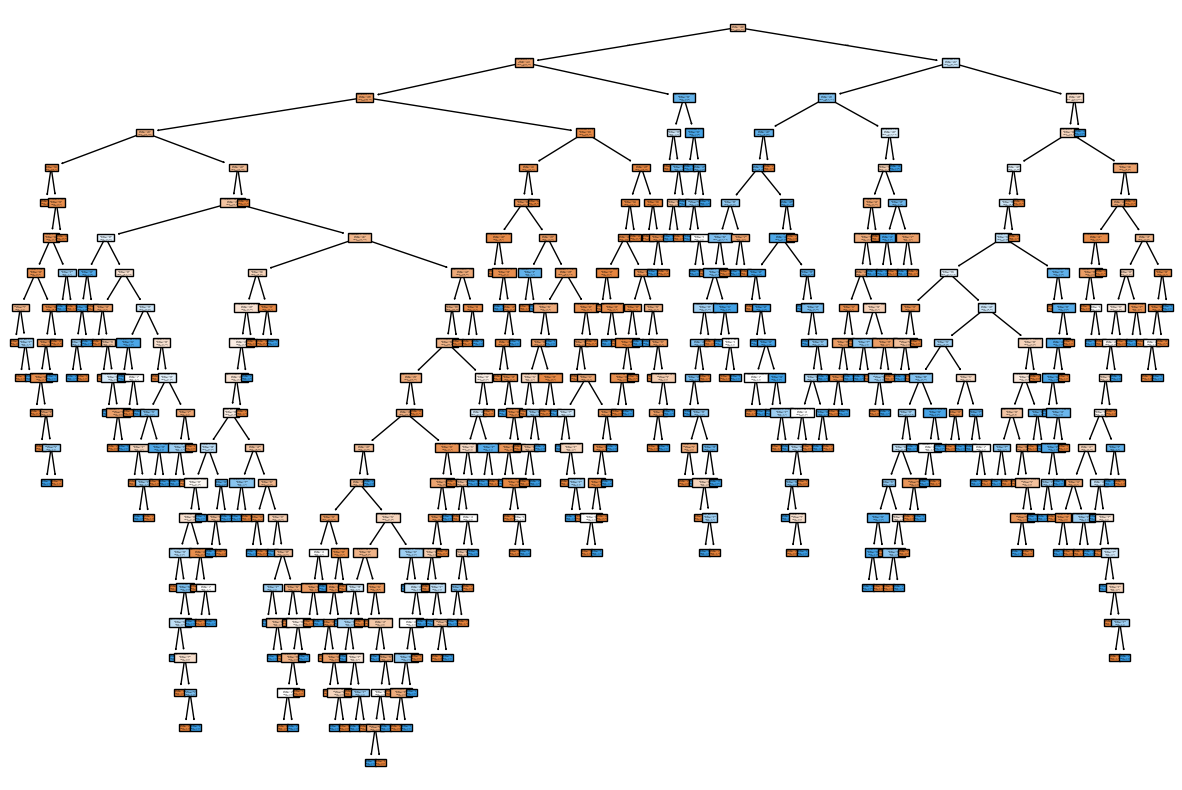

In [28]:
fig = plt.figure(figsize=(15, 10))

tree_graph = tree.plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True
);

In [29]:
y_pred_train_tree = tree_model.predict(X_train)

print(metrics.classification_report(y_train, y_pred_train_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1271
           1       1.00      1.00      1.00       610

    accuracy                           1.00      1881
   macro avg       1.00      1.00      1.00      1881
weighted avg       1.00      1.00      1.00      1881



In [30]:
y_pred_test_tree = tree_model.predict(X_test)

print(metrics.classification_report(y_test, y_pred_test_tree))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       424
           1       0.54      0.51      0.53       204

    accuracy                           0.70       628
   macro avg       0.66      0.65      0.65       628
weighted avg       0.70      0.70      0.70       628



> Ваши выводы и рассуждения — *здесь*

По выводу из модели дерева решений сделать вывод очень просто. Согласно результату модели по тренировачным данным, дерево прекрасно справилась с предсказанием ответов. Модель имеет идеальные значения метрик (precision, recall и f1-score равны 1.0). Однако, согласно результату метрик по предсказанию дерева по тестовой наборке, модель имеет плохую обощающую способность и переобучение. 

Причиной такого поведения является отсутствие ограничения глубины дерева, из за чего модель чрезмерно подстраивается под обучающую выборку. Разбивая пространство признаков на множество мелких областей, дерево фактически запоминает ответы, что приводит к ухудшению качества на новых данных. 

### Задание 8.2. (1 балл)

Давайте «подстрижём» наше дерево. 

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с максимальной глубиной 8. В качестве критерия информативности используйте энтропию Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните результат с полученными ранее. Сделайте вывод.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [31]:
# Ваш код здесь
tree_model_new = tree.DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=10, random_state=42)
tree_model_new.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

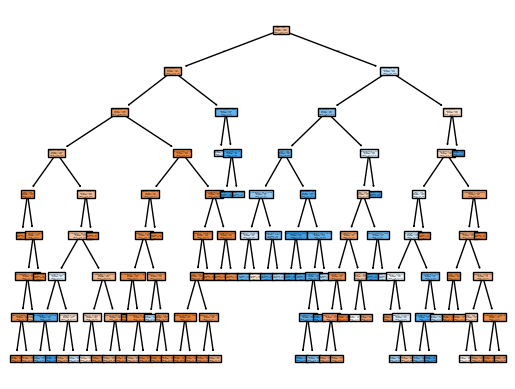

In [32]:
tree_graph_new = tree.plot_tree(
    tree_model_new, 
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True
);

In [33]:
y_pred_train_tree_new = tree_model_new.predict(X_train)
y_pred_test_tree_new = tree_model_new.predict(X_test)

print(metrics.classification_report(y_train, y_pred_train_tree_new))
print(metrics.classification_report(y_test, y_pred_test_tree_new))


              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1271
           1       0.80      0.65      0.72       610

    accuracy                           0.83      1881
   macro avg       0.82      0.79      0.80      1881
weighted avg       0.83      0.83      0.83      1881

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       424
           1       0.72      0.59      0.65       204

    accuracy                           0.79       628
   macro avg       0.77      0.74      0.75       628
weighted avg       0.79      0.79      0.79       628



> Ваши выводы и рассуждения — *здесь*

По полученным результатам метрики, благодаря указанию ограничения глубины дерева на 8, я получил устойчивую, чем предыдущую, модель. Это значит, что она стала менее переобученной.

По результату видно, что разница между train и test выборок при обучении уменьшилась, это означает что модель tree_model_new более устойчива, чем tree_model и tree_model_new имеет лучшую обощающую способность.

### Задание 8.3. (1 балл)

Давайте воспользуемся случайным лесом. 

Постройте случайный лес (`RandomForestClassifier`) из 500 деревьев с максимальной глубиной 8. Критерий информативности — энтропия Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните качество одного дерева решений с качеством случайного леса на тестовой выборке. Смогли ли вы улучшить метрику?


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [34]:
# Ваш код здесь
ensemble_model = ensemble.RandomForestClassifier(n_estimators=500, max_depth=8, criterion='entropy', min_samples_leaf=10, random_state=42)
ensemble_model.fit(X_train, y_train)

pred_train_ensemble = ensemble_model.predict(X_train)
pred_test_ensemble = ensemble_model.predict(X_test)

In [35]:
print(metrics.classification_report(y_train, pred_train_ensemble))
print(metrics.classification_report(y_test, pred_test_ensemble))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1271
           1       0.86      0.63      0.73       610

    accuracy                           0.85      1881
   macro avg       0.85      0.79      0.81      1881
weighted avg       0.85      0.85      0.84      1881

              precision    recall  f1-score   support

           0       0.81      0.90      0.86       424
           1       0.74      0.57      0.64       204

    accuracy                           0.79       628
   macro avg       0.78      0.74      0.75       628
weighted avg       0.79      0.79      0.79       628



> Ваши выводы и рассуждения — *здесь*

Я построил ансамблевую модель случайного леса, которая показала стабильные результаты по сравнению с деревом решений. По сравнению с ограниченным деревом результаты метрик на тестовой выборке остались на том же уровне, однако модель стала менее переобученной и более устойчивой, что логично, так как случайный лес обучается на множестве деревьев (в данном случает на 500) и в результате итоговое предсказание формируется за счет усреднения ответов всех деревьев ансамбля, который дает стабильный и приемлемый результат. 

### Задание 8.4. (2 балла)

Мы на финишной прямой. 


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. **Используйте ту модель (из рассмотренных ранее), которая показала наилучшее качество на тестовой выборке.**


В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список. 

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните полученный результат с полученными ранее. 

Напишите небольшой вывод о проделанной работе, указав в нём, какая из рассмотренных нами моделей показала наилучший результат.

> **Примечание.** Помните о том, что в реальных задачах (а мы решали задачу на реальных данных) мы практически никогда не сможем получить значения метрик, близкие к 1. Если в задаче прогнозирования оттока ваша метрика превышает хотя бы значения 0.6-0.7, вашу модель уже можно считать хорошей и можно говорить о том, что она успешно справляется с задачей.

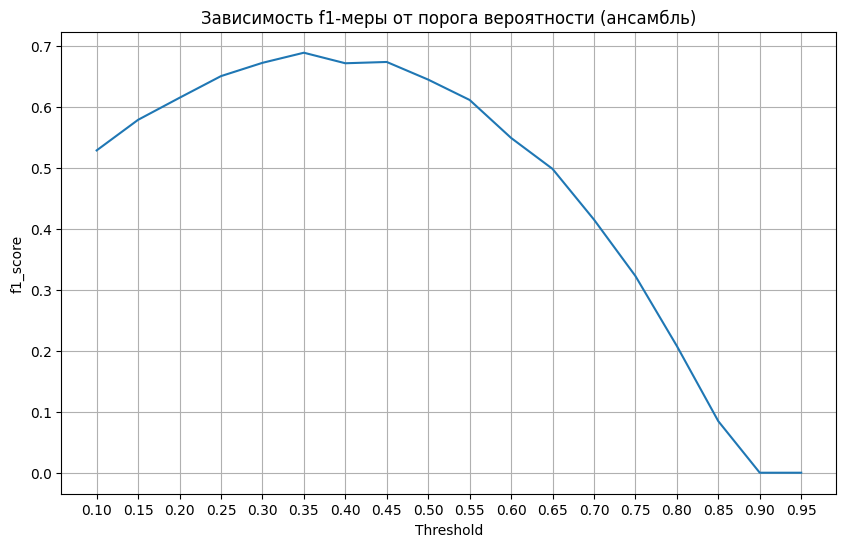

In [36]:
# Ваш код здесь
y_test_proba_ensemble = pd.Series(ensemble_model.predict_proba(X_test)[:, 1])
scores = []
thresholds = np.arange(0.1, 1, 0.05)

for threshold in thresholds:
    y_test_pred_ensemble = y_test_proba_ensemble.apply(lambda x: 1 if x > threshold else 0)
    score = metrics.f1_score(y_test, y_test_pred_ensemble)
    scores.append(score)

# График
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, scores)
ax.set_xticks(thresholds)
ax.set_title('Зависимость f1-меры от порога вероятности (ансамбль)')
plt.grid(True)
plt.xlabel('Threshold')
plt.ylabel('f1_score')
display()

In [37]:
best_score_ensemble = max(scores)
best_threshold_ensemble = thresholds[scores.index(best_score_ensemble)]

y_test_pred_best_ensemble = y_test_proba_ensemble.apply(lambda x: 1 if x > best_threshold_ensemble else 0)
print("Best threshold:", best_threshold_ensemble)
print("F1:", f1_score(y_test, y_test_pred_best_ensemble))
print("Precision:", precision_score(y_test, y_test_pred_best_ensemble))
print("Recall:", recall_score(y_test, y_test_pred_best_ensemble))
print("Accuracy:", accuracy_score(y_test, y_test_pred_best_ensemble))

Best threshold: 0.3500000000000001
F1: 0.6887417218543046
Precision: 0.6265060240963856
Recall: 0.7647058823529411
Accuracy: 0.7754777070063694


> Ваши выводы и рассуждения — *здесь*

При нахождении оптимального порога вероятности для ансамблевой модели я получил 0.35 как оптимальную границу. При таком значении не смотря на ухудшение accuracy я получил более сбалансированную f1-меру (0.688) и recall (0.764), что полностью оправдывает снижение accuracy, ведь в моделях такого вида (churn) мы стараемся получить наилучший ответ от модели по действительно уходящим клиентам, а не то как модель ошибается на стабильных клиентах.

### Задание 8.5. (1 балл)

Наконец, финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

С помощью наилучшей модели спрогнозируйте вероятность того, что Василий откажется от услуг банка.

> **Примечание.** Учтите, что для предсказания необходимо преобразовать данные к тому формату, на котором обучалась модель, то есть:
* добавить признаки дополнительные признаки; 
* произвести кодирование категориальных признаков;
* произвести масштабирование признаков (если ваша модель обучалась на масштабированных данных) с помощью того же скейлера, который вы использовали при обучении модели;
* сгенерировать полиномиальные признаки.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * сформирован DataFrame на основе предоставленного словаря;
    * произведены преобразования данных, необходимые для работы модели;
    * предсказана вероятность оттока клиента (вероятность принадлежности к классу 1).

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [38]:
# Ваш код здесь
X_test_Vasiliy = pd.DataFrame(
    {
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
)

X_test_Vasiliy['BalanceSalaryRatio'] = X_test_Vasiliy['Balance']/X_test_Vasiliy['EstimatedSalary']
X_test_Vasiliy['TenureByAge'] = X_test_Vasiliy['Tenure'] / X_test_Vasiliy['Age']
X_test_Vasiliy['CreditScoreGivenAge'] = X_test_Vasiliy['CreditScore'] / X_test_Vasiliy['Age']

gender_encoded_Vasiliy = pd.get_dummies(X_test_Vasiliy, columns=['Gender'], drop_first=False)
X_test_Vasiliy = gender_encoded_Vasiliy
X_test_Vasiliy.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Male
0,601.0,42.0,1.0,98495.72,1.0,1.0,0.0,40014.76,2.461485,0.02381,14.309524,True


In [39]:
# Ваш код здесь
# Кодировка
X_test_Vasiliy[value_categories] = scaler.transform(X_test_Vasiliy[value_categories])

In [40]:
# Результат модели
result_Vasiliy = ensemble_model.predict_proba(X_test_Vasiliy)

print(f'С вероятностью {round(result_Vasiliy[0][1]*100)}% Василий уйдет из банка')

С вероятностью 34% Василий уйдет из банка


## Финальный вывод

В ходе проекта я построил модель несколько моделей для прогнозирования оттока клиентов банка: логистическая регрессия, логистическая регрессия с полиномиальными признаками, дерево решений и случайный лес. 

Лучший результат после подбора порога показала ансамблевая модель Random Forest: F1-score составил около 0.68874, recall — около 0.76470. Это означает, что модель стала лучше находить клиентов, склонных к оттоку, что особенно важно для задачи удержания клиентов.